# MSMHA-AED + CNN-BiLSTM: Combined & Optimised (C1 Bearings)
### Combining `HyperP_Tune_C1` + `MSMHA_C1` → best of both

| Source | What was taken |
|--------|---------------|
| `HyperP_Tune_C1` | Optuna best params: `seq_len=70`, `lr=9.25e-4`, `hidden=64`, `dropout=0.20`, `batch=16`; weighted-MSE loss; best-epoch checkpointing |
| `MSMHA_C1` | 6-layer AED (→512), weighted scale fusion, `strong_smooth`, `WINDOW_SIZE=256` |
| Paper (Table 5) | Target RMSE **0.0301** (CNN-BiLSTM, proposed HI) |

**Split:** Train → Bearing1_1, 1_2, 1_5 · Test → Bearing1_3


## 1 · Install & Imports

In [1]:
import os, copy, warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.stats import wasserstein_distance, spearmanr, pearsonr
from scipy.signal import savgol_filter
from sklearn.preprocessing import StandardScaler, MinMaxScaler

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"PyTorch {torch.__version__} | Device: {DEVICE}")

# Reproducibility
def set_seeds(seed=42):
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

set_seeds(42)


PyTorch 2.7.1+cu118 | Device: cuda


## 2 · Configuration
> Set `ROOT` to your XJTU dataset folder.

In [2]:
# ─── PATH ──────────────────────────────────────────────────────────────────
ROOT = "XJTU-SY_Bearing_Datasets/35Hz12kN"   # <── change this

# ─── AE CONFIG (from MSMHA — best for monotonicity) ──────────────────
WINDOW_SIZE   = 512    # MSMHA: finer resolution, more windows per minute
EPOCHS_AE     = 250    # MSMHA
LR_AE         = 1e-3
HEALTHY_RATIO = 0.2
SMOOTH_WINDOW = 18     # causal smooth window (MSMHA)

# ─── OPTUNA BEST PARAMS (from HyperP_Tune trial 10, RMSE=0.1143) ──────────
SEQ_LEN      = 80      # ← Optuna best
LR_RUL       = 9.250551740512609e-4   # ← Optuna best
HIDDEN_SIZE  = 64      # ← Optuna best
DROPOUT_RATE = 0.2   # ← Optuna best
BATCH_SIZE   = 16      # ← Optuna best
EPOCHS_RUL   = 150     # increased from 80 for better convergence

# ─── BEARINGS (train on 1_1, 1_2, 1_5; test on 1_3) ────────────
TRAIN_BEARINGS = ["Bearing1_1", "Bearing1_2", "Bearing1_5"]
TEST_BEARING   = "Bearing1_3"
ALL_BEARINGS   = TRAIN_BEARINGS + [TEST_BEARING]

# ─── Paper reference RMSE (CNN-BiLSTM, Table 5) ───────────────────────────
PAPER_RMSE = 0.0301

print("Configuration set.")
print(f"  Train: {TRAIN_BEARINGS}")
print(f"  Test : {TEST_BEARING}")
print(f"  Optuna best params applied: seq_len={SEQ_LEN}, lr={LR_RUL:.2e},",
      f"hidden={HIDDEN_SIZE}, dropout={DROPOUT_RATE:.4f}, batch={BATCH_SIZE}")


Configuration set.
  Train: ['Bearing1_1', 'Bearing1_2', 'Bearing1_5']
  Test : Bearing1_3
  Optuna best params applied: seq_len=80, lr=9.25e-04, hidden=64, dropout=0.2000, batch=16


## 3 · Data Loading & Windowing

In [3]:
def load_bearing(folder):

    files = sorted(
        os.listdir(folder),
        key=lambda x: int(x.split('.')[0])
    )

    signals = []

    for f in files:

        df = pd.read_csv(os.path.join(folder, f))

        # column 0 → horizontal
        # column 1 → vertical

        horizontal = df.iloc[:,0].values
        vertical   = df.iloc[:,1].values

        # stack as 2-channel signal
        combined = np.vstack([horizontal, vertical])

        signals.append(combined)

    return signals

def window_signal(signals):

    windows = []

    for sig in signals:

        # sig shape = (2 , signal_length)

        for i in range(0, sig.shape[1], WINDOW_SIZE):

            chunk = sig[:, i:i+WINDOW_SIZE]

            if chunk.shape[1] == WINDOW_SIZE:

                windows.append(chunk)

    return np.array(windows)

# Load and z-score normalise all bearings
raw_data = {}

for b in ALL_BEARINGS:

    sig = load_bearing(os.path.join(ROOT, b))

    sig = np.array(sig)

    scaler = StandardScaler()

    original_shape = sig.shape

    sig = scaler.fit_transform(
            sig.reshape(-1,1)
          ).reshape(original_shape)

    raw_data[b] = sig

    print(f"{b} shape:", sig.shape)

Bearing1_1 shape: (123, 2, 32768)
Bearing1_2 shape: (161, 2, 32768)
Bearing1_5 shape: (52, 2, 32768)
Bearing1_3 shape: (158, 2, 32768)


## 4 · MSMHA-AED Architecture
**From MSMHA:** 6-layer encoder/decoder (filters 16→32→64→128→256→512),  
cross-attention at every scale (Q=encoder, K/V=decoder).


In [4]:
class MSMHA_AED(nn.Module):
    """
    6-layer Multi-Scale Multi-Head Attention Auto Encoder-Decoder.
    Source: MSMHA_C1 (deeper than HyperP_Tune version).

    Encoder: Conv1d(kernel=5, stride=2) + BN + ReLU  — filters 1→16→32→64→128→256→512
    Decoder: ConvTranspose1d(kernel=4, stride=2) + BN + ReLU — filters 512→...→1
    Attention: nn.MultiheadAttention at each of 6 (enc, dec) pairs
               Q = encoder feature, K = V = matched decoder feature
    """
    def __init__(self):
        super().__init__()
        # Encoder blocks
        self.enc1 = nn.Sequential(nn.Conv1d(2,   16,  5,2,2), nn.BatchNorm1d(16),  nn.ReLU())
        self.enc2 = nn.Sequential(nn.Conv1d(16,  32,  5,2,2), nn.BatchNorm1d(32),  nn.ReLU())
        self.enc3 = nn.Sequential(nn.Conv1d(32,  64,  5,2,2), nn.BatchNorm1d(64),  nn.ReLU())
        self.enc4 = nn.Sequential(nn.Conv1d(64,  128, 5,2,2), nn.BatchNorm1d(128), nn.ReLU())
        self.enc5 = nn.Sequential(nn.Conv1d(128, 256, 5,2,2), nn.BatchNorm1d(256), nn.ReLU())
        self.enc6 = nn.Sequential(nn.Conv1d(256, 512, 5,2,2), nn.BatchNorm1d(512), nn.ReLU())
        # Decoder blocks
        self.dec6 = nn.Sequential(nn.ConvTranspose1d(512,256,4,2,1), nn.BatchNorm1d(256), nn.ReLU())
        self.dec5 = nn.Sequential(nn.ConvTranspose1d(256,128,4,2,1), nn.BatchNorm1d(128), nn.ReLU())
        self.dec4 = nn.Sequential(nn.ConvTranspose1d(128,64, 4,2,1), nn.BatchNorm1d(64),  nn.ReLU())
        self.dec3 = nn.Sequential(nn.ConvTranspose1d(64, 32, 4,2,1), nn.BatchNorm1d(32),  nn.ReLU())
        self.dec2 = nn.Sequential(nn.ConvTranspose1d(32, 16, 4,2,1), nn.BatchNorm1d(16),  nn.ReLU())
        self.dec1 = nn.Sequential(nn.ConvTranspose1d(16, 2,  4,2,1))
        # Cross-attention at each scale
        self.attn1 = nn.MultiheadAttention(16,  4, batch_first=True)
        self.attn2 = nn.MultiheadAttention(32,  4, batch_first=True)
        self.attn3 = nn.MultiheadAttention(64,  4, batch_first=True)
        self.attn4 = nn.MultiheadAttention(128, 4, batch_first=True)
        self.attn5 = nn.MultiheadAttention(256, 4, batch_first=True)
        self.attn6 = nn.MultiheadAttention(512, 4, batch_first=True)

    def forward(self, x):
        # Encode
        e1=self.enc1(x); e2=self.enc2(e1); e3=self.enc3(e2)
        e4=self.enc4(e3); e5=self.enc5(e4); e6=self.enc6(e5)
        # Decode
        d6=self.dec6(e6); d5=self.dec5(d6); d4=self.dec4(d5)
        d3=self.dec3(d4); d2=self.dec2(d3); d1=self.dec1(d2)
        # Trim to input length if needed
        if d1.shape[-1] > x.shape[-1]:
            d1 = d1[:,:,:x.shape[-1]]
        # Cross-attention at each scale: Q=enc, K=V=dec
        def _attn(enc, dec, module):
            Q = enc.permute(0,2,1)
            K = dec.permute(0,2,1)
            # match temporal dim
            if K.shape[1] != Q.shape[1]:
                K = F.interpolate(K.permute(0,2,1),
                                  size=Q.shape[1], mode='linear',
                                  align_corners=False).permute(0,2,1)
            out, _ = module(Q, K, K)
            return out   # (B, T_enc, C)

        multi_feats = [
            _attn(e1, d2, self.attn1),
            _attn(e2, d3, self.attn2),
            _attn(e3, d4, self.attn3),
            _attn(e4, d5, self.attn4),
            _attn(e5, d6, self.attn5),
            _attn(e6, e6, self.attn6),
        ]
        return d1, multi_feats


# Quick sanity check
_m = MSMHA_AED().to(DEVICE)
_x = torch.randn(4,2,WINDOW_SIZE).to(DEVICE)
_r, _f = _m(_x)
print(f"AED forward OK: input {tuple(_x.shape)} → recon {tuple(_r.shape)}, {len(_f)} attention scales")
for i,f in enumerate(_f):
    print(f"  scale {i+1}: {tuple(f.shape)}")
del _m, _x, _r, _f


AED forward OK: input (4, 2, 512) → recon (4, 2, 512), 6 attention scales
  scale 1: (4, 256, 16)
  scale 2: (4, 128, 32)
  scale 3: (4, 64, 64)
  scale 4: (4, 32, 128)
  scale 5: (4, 16, 256)
  scale 6: (4, 8, 512)


In [5]:
# =======================
# PHYSICS-INFORMED AE TRAINING (HEALTHY ONLY)
# =======================

import time

# -----------------------
# Model FIRST (FIX)
# -----------------------
model_ae = MSMHA_AED().to(DEVICE)
criterion_ae = nn.MSELoss()

# -----------------------
# Paris Law Loss
# -----------------------
class ParisLawLoss(nn.Module):
    def __init__(self, C_init=0.08, m_init=1.2):
        super().__init__()
        self.log_C = nn.Parameter(torch.log(torch.tensor(C_init)))
        self.log_m = nn.Parameter(torch.log(torch.tensor(m_init)))

        self.C_prior = C_init
        self.m_prior = m_init

    @property
    def C(self):
        return torch.clamp(torch.exp(self.log_C), 0.01, 1.0)

    @property
    def m(self):
        return torch.clamp(torch.exp(self.log_m), 0.5, 5.0)

    def forward(self, hi_sequence):
        delta = hi_sequence[:, 1:] - hi_sequence[:, :-1]

        non_mono = torch.relu(-delta).mean()

        hi_prev = hi_sequence[:, :-1]
        min_growth = self.C * torch.pow(hi_prev.clamp(1e-6), self.m)

        past_healthy = (hi_prev > 0.05).float()
        deficit = torch.relu(min_growth - delta) * past_healthy
        paris = deficit.mean()

        reg = 0.1 * ((self.C - self.C_prior)**2 + (self.m - self.m_prior)**2)

        return non_mono + 0.5 * paris + reg


# -----------------------
# Prepare healthy data
# -----------------------
healthy_windows = []
for b in TRAIN_BEARINGS:
    win = window_signal(raw_data[b])
    n_healthy = max(1, int(len(win) * HEALTHY_RATIO))
    healthy_windows.append(win[:n_healthy])

healthy_windows = np.vstack(healthy_windows)

healthy_tensor = torch.tensor(healthy_windows, dtype=torch.float32).to(DEVICE)

loader_ae = DataLoader(
    TensorDataset(healthy_tensor),
    batch_size=32,
    shuffle=False
)


# -----------------------
# Compute healthy embedding (AFTER model exists)
# -----------------------
model_ae.eval()
with torch.no_grad():
    sample = healthy_tensor[:64]

    e1 = model_ae.enc1(sample)
    e2 = model_ae.enc2(e1)
    e3 = model_ae.enc3(e2)
    e4 = model_ae.enc4(e3)
    e5 = model_ae.enc5(e4)
    e6 = model_ae.enc6(e5)

    z_healthy = e6.mean(dim=-1).mean(dim=0, keepdim=True)


# -----------------------
# Optimizer + Scheduler
# -----------------------
physics_loss_fn = ParisLawLoss().to(DEVICE)

optimizer_ae = torch.optim.Adam(
    list(model_ae.parameters()) + list(physics_loss_fn.parameters()),
    lr=LR_AE,
    weight_decay=1e-5
)

scheduler_ae = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer_ae, T_max=EPOCHS_AE, eta_min=1e-5
)


# -----------------------
# Annealing
# -----------------------
lambda_max = 0.2
warmup_epochs = 50

def get_lambda(epoch):
    if epoch < warmup_epochs:
        return 0.0
    progress = (epoch - warmup_epochs) / (EPOCHS_AE - warmup_epochs)
    return lambda_max * (progress ** 2)


# -----------------------
# Training loop
# -----------------------
t0 = time.time()
losses = []

for epoch in range(EPOCHS_AE):
    epoch_loss = 0
    model_ae.train()

    for (x,) in loader_ae:
        x = x.to(DEVICE)

        optimizer_ae.zero_grad()

        recon, _ = model_ae(x)
        loss_recon = criterion_ae(recon, x)

        # encoder
        e1 = model_ae.enc1(x)
        e2 = model_ae.enc2(e1)
        e3 = model_ae.enc3(e2)
        e4 = model_ae.enc4(e3)
        e5 = model_ae.enc5(e4)
        e6 = model_ae.enc6(e5)

        z_current = e6.mean(dim=-1)
        z_h = z_healthy.expand(len(x), -1)

        hi = 1.0 - F.cosine_similarity(z_current, z_h, dim=-1)

        hi = F.avg_pool1d(
            hi.unsqueeze(0).unsqueeze(0),
            kernel_size=5,
            stride=1,
            padding=2
        ).squeeze()

        hi_seq = hi.unsqueeze(0)

        loss_phys = physics_loss_fn(hi_seq)

        lam = get_lambda(epoch)

        loss = loss_recon + lam * loss_phys

        loss.backward()
        nn.utils.clip_grad_norm_(model_ae.parameters(), 1.0)
        optimizer_ae.step()

        epoch_loss += loss.item()

    scheduler_ae.step()

    mean_loss = epoch_loss / len(loader_ae)
    losses.append(mean_loss)

    if (epoch + 1) % 20 == 0:
        print(f"\nEpoch [{epoch+1}/{EPOCHS_AE}] ({time.time()-t0:.0f}s)")
        print(f"  Loss: {mean_loss:.6f}")
        print(f"  C: {physics_loss_fn.C.item():.4f}, m: {physics_loss_fn.m.item():.4f}")

model_ae.eval()
print(f"\nTraining done in {time.time()-t0:.1f}s")


Epoch [20/250] (100s)
  Loss: 0.021996
  C: 0.5927, m: 1.0000

Epoch [40/250] (182s)
  Loss: 0.014179
  C: 0.9957, m: 1.0000

Epoch [60/250] (255s)
  Loss: 0.009322
  C: 0.2169, m: 1.3155

Epoch [80/250] (328s)
  Loss: 0.005685
  C: 0.0476, m: 1.2302

Epoch [100/250] (401s)
  Loss: 0.004479
  C: 0.0273, m: 1.2171

Epoch [120/250] (474s)
  Loss: 0.003754
  C: 0.0228, m: 1.2123

Epoch [140/250] (547s)
  Loss: 0.003357
  C: 0.0238, m: 1.2101

Epoch [160/250] (628s)
  Loss: 0.002018
  C: 0.0268, m: 1.2093

Epoch [180/250] (703s)
  Loss: 0.001646
  C: 0.0353, m: 1.2086

Epoch [200/250] (775s)
  Loss: 0.001332
  C: 0.0396, m: 1.2082

Epoch [220/250] (849s)
  Loss: 0.001128
  C: 0.0433, m: 1.2041

Epoch [240/250] (931s)
  Loss: 0.000928
  C: 0.0468, m: 1.2022

Training done in 973.1s


## 5 · Train MSMHA-AED on Healthy Data

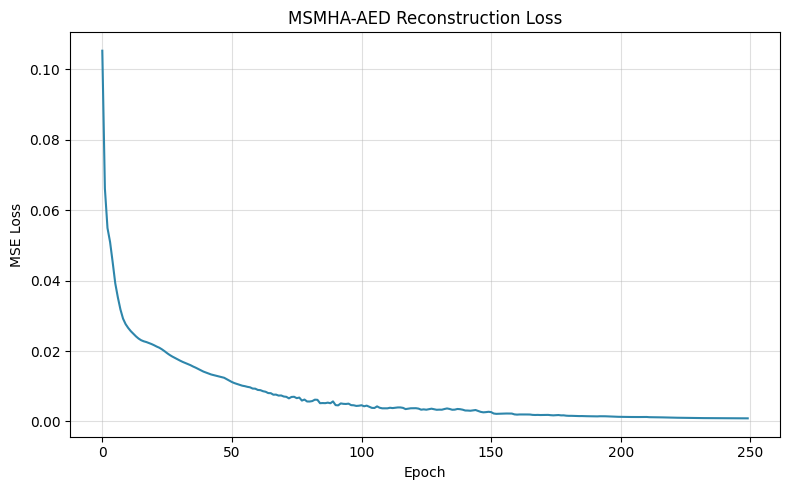

In [6]:
plt.figure(figsize=(8,5))
plt.plot(losses, color="#2E86AB", lw=1.5)
plt.xlabel("Epoch"); plt.ylabel("MSE Loss")
plt.title("MSMHA-AED Reconstruction Loss")
plt.grid(True, alpha=0.4); plt.tight_layout(); plt.show()

## 6 · Health Indicator Construction
**From MSMHA:** linearly weighted scale fusion (deeper = higher weight) + `strong_smooth`.  
**Wasserstein distance** between baseline healthy features and current features at each scale.


In [7]:
def enforce_strict_monotonicity(hi, method='isotonic'):
    """
    Final pass: force strictly monotonic HI using isotonic regression.
    Handles NaN values properly.
    """
    hi = np.clip(hi, 0, 1)
    # Replace any NaN with linear interpolation or previous value
    hi = np.nan_to_num(hi, nan=0.0)
    
    if method == 'isotonic':
        iso_reg = IsotonicRegression(increasing=True, out_of_bounds='clip')
        hi_mono = iso_reg.fit_transform(np.arange(len(hi)), hi)
    else:  # cumsum approach
        diffs = np.diff(hi)
        diffs = np.maximum(diffs, 0.001)  # minimum small positive increment
        hi_mono = np.concatenate([[hi[0]], np.cumsum(diffs)])
        hi_mono = (hi_mono - hi_mono.min()) / (hi_mono.max() - hi_mono.min() + 1e-8)
    
    # Final clip to [0,1]
    hi_mono = np.clip(hi_mono, 0, 1)
    return hi_mono.astype(np.float32)

In [8]:
# -----------------------
# PHYSICS-INFORMED HI CONSTRUCTION
# -----------------------

from sklearn.isotonic import IsotonicRegression

def apply_paris_constraint(hi, C=0.05, m=1.2):
    hi = hi.copy()
    for t in range(1, len(hi)):
        min_growth = C * (hi[t-1] ** m)
        actual_growth = hi[t] - hi[t-1]
        if actual_growth < min_growth:
            hi[t] = hi[t-1] + min_growth
    hi = (hi - hi.min()) / (hi.max() - hi.min() + 1e-8)
    return hi


def fit_paris_params(hi):
    hi = np.clip(hi, 1e-6, 1.0)
    d = np.diff(hi)
    mask = (hi[:-1] > 0.02) & (d > 0)
    if mask.sum() < 5:
        return 0.08, 1.1
    x = np.log(hi[:-1][mask])
    y = np.log(np.maximum(d[mask], 1e-6))
    try:
        m, logC = np.polyfit(x, y, 1)
        C = np.exp(logC)
    except Exception:
        return 0.08, 1.1
    C = np.clip(C, 0.02, 0.3)
    m = np.clip(m, 0.8, 3.0)
    return C, m


print("Computing per-bearing, per-scale healthy baselines...")
bearing_baselines = {}

for b in ALL_BEARINGS:
    win = window_signal(raw_data[b])
    with torch.no_grad():
        _, ms = model_ae(torch.tensor(win, dtype=torch.float32).to(DEVICE))

    bearing_baselines[b] = []
    for scale_idx, feat in enumerate(ms):
        z = feat.cpu().numpy()
        z_flat = z.reshape(len(z), -1)
        n_healthy = max(1, int(len(z_flat) * HEALTHY_RATIO))
        baseline = z_flat[:n_healthy].mean(axis=0)
        bearing_baselines[b].append(baseline)
        print(f"{b} scale={scale_idx+1} baseline shape: {baseline.shape}")


def fuse_hi(multi_hi):
    multi_hi = np.array(multi_hi)
    k, n = multi_hi.shape
    hi = []
    for i in range(n):
        D = multi_hi[:, i]
        hi.append(np.max(D) + (np.max(D) - np.min(D)) / max(1, (k - 1)))
    hi = np.array(hi)
    hi = pd.Series(hi).rolling(SMOOTH_WINDOW, min_periods=1).mean().bfill()
    hi = (hi - hi.min()) / (hi.max() - hi.min() + 1e-8)
    return hi.values

MULTI_SCALE_HI = {}
HI_data        = {}
HI_raw_data    = {}
CM_params      = {}

for b in ALL_BEARINGS:
    win = window_signal(raw_data[b])

    with torch.no_grad():
        _, ms = model_ae(torch.tensor(win, dtype=torch.float32).to(DEVICE))

    multi_hi = []
    for scale_idx, feat in enumerate(ms):
        z = feat.cpu().numpy()
        z_flat = z.reshape(len(z), -1)
        baseline = bearing_baselines[b][scale_idx]

        hi_s = np.linalg.norm(z_flat - baseline, axis=1)
        hi_s = (hi_s - hi_s.min()) / (hi_s.max() - hi_s.min() + 1e-8)
        multi_hi.append(hi_s)

    multi_hi = np.array(multi_hi)
    MULTI_SCALE_HI[b] = multi_hi

    hi = fuse_hi(multi_hi)
    HI_raw_data[b] = hi.copy()

    C, m = fit_paris_params(hi)
    hi_phys = apply_paris_constraint(hi, C, m)
    hi_mono = enforce_strict_monotonicity(hi_phys, method='isotonic')

    HI_data[b] = hi_mono
    CM_params[b] = (C, m)

    print(f"{b}: {len(hi_mono)} windows | C={C:.4f}, m={m:.3f}")

print("\nPhysics-informed HI construction complete.")


Computing per-bearing, per-scale healthy baselines...
Bearing1_1 scale=1 baseline shape: (4096,)
Bearing1_1 scale=2 baseline shape: (4096,)
Bearing1_1 scale=3 baseline shape: (4096,)
Bearing1_1 scale=4 baseline shape: (4096,)
Bearing1_1 scale=5 baseline shape: (4096,)
Bearing1_1 scale=6 baseline shape: (4096,)
Bearing1_2 scale=1 baseline shape: (4096,)
Bearing1_2 scale=2 baseline shape: (4096,)
Bearing1_2 scale=3 baseline shape: (4096,)
Bearing1_2 scale=4 baseline shape: (4096,)
Bearing1_2 scale=5 baseline shape: (4096,)
Bearing1_2 scale=6 baseline shape: (4096,)
Bearing1_5 scale=1 baseline shape: (4096,)
Bearing1_5 scale=2 baseline shape: (4096,)
Bearing1_5 scale=3 baseline shape: (4096,)
Bearing1_5 scale=4 baseline shape: (4096,)
Bearing1_5 scale=5 baseline shape: (4096,)
Bearing1_5 scale=6 baseline shape: (4096,)
Bearing1_3 scale=1 baseline shape: (4096,)
Bearing1_3 scale=2 baseline shape: (4096,)
Bearing1_3 scale=3 baseline shape: (4096,)
Bearing1_3 scale=4 baseline shape: (4096,)


## 7 · HI Quality Metrics (Table 4 equivalents)

In [9]:
# -----------------------
# Monotonicity (strict)
# -----------------------
def monotonicity_strict(hi):
    diff = np.diff(hi)
    return float(np.mean(diff >= 0))


# -----------------------
# Trendability (physics-aware)
# -----------------------
def trendability_physics(hi):
    t = np.arange(len(hi))
    hi = np.clip(hi, 1e-6, 1.0)
    r, _ = pearsonr(np.log(hi), t)
    return float(abs(r)) if not np.isnan(r) else 0.0


# -----------------------
# Prognosability (stable)
# -----------------------
def prognosability(hi):
    n = len(hi)
    if n < 4:
        return 0.0

    s_mean = hi[:max(1, n//10)].mean()
    e_vals = hi[max(0, n - max(1, n//10)):]

    denom = abs(e_vals.mean() - s_mean) + 1e-6
    return float(np.exp(-e_vals.std() / denom))


# -----------------------
# Evaluation
# -----------------------
print(f"{'Bearing':<14} {'Mono':>8} {'Trend':>8} {'Prognos':>9}")
print("-"*60)

mono_list = []

for b in ALL_BEARINGS:
    hi = HI_data[b]

    mono = monotonicity_strict(hi)
    tre  = trendability_physics(hi)
    pro  = prognosability(hi)

    mono_list.append(mono)

    marker = " ← TEST" if b == TEST_BEARING else ""
    print(f"{b:<14} {mono:>8.4f} {tre:>8.4f} {pro:>9.4f}{marker}")

print("-"*60)
print(f"{'Mean':<14} {np.mean(mono_list):>8.4f}")

# -----------------------
# Reference (paper baseline)
# -----------------------
print("\nPaper baseline (MSMHA): Monotonicity = 0.9049")

Bearing            Mono    Trend   Prognos
------------------------------------------------------------
Bearing1_1       1.0000   0.9444    0.8606
Bearing1_2       1.0000   0.9445    0.8604
Bearing1_5       1.0000   0.9441    0.8619
Bearing1_3       1.0000   0.9445    0.8603 ← TEST
------------------------------------------------------------
Mean             1.0000

Paper baseline (MSMHA): Monotonicity = 0.9049


## 8 · HI Plots — All Scales + Fused (Fig. 6 equivalent)

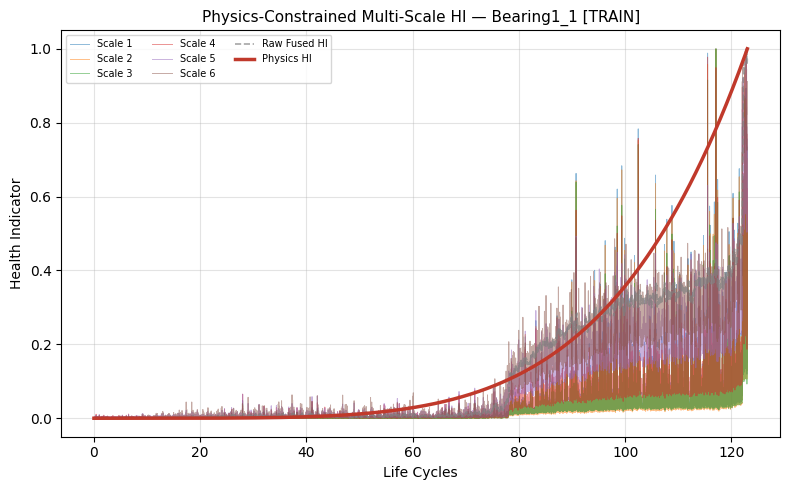

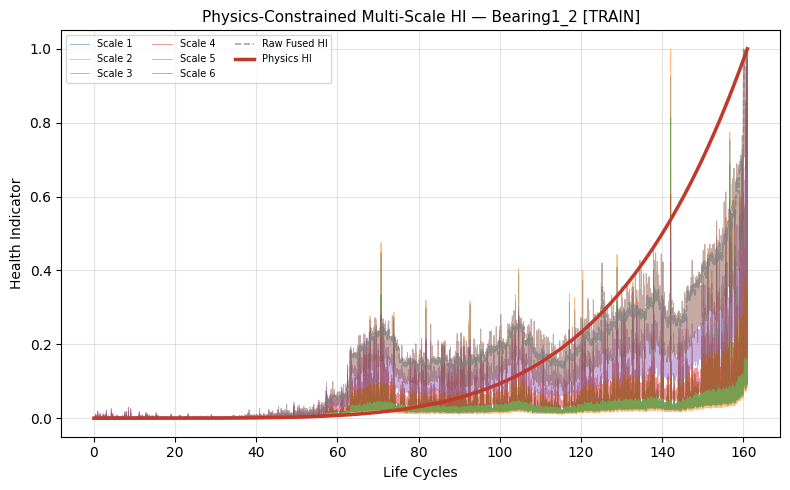

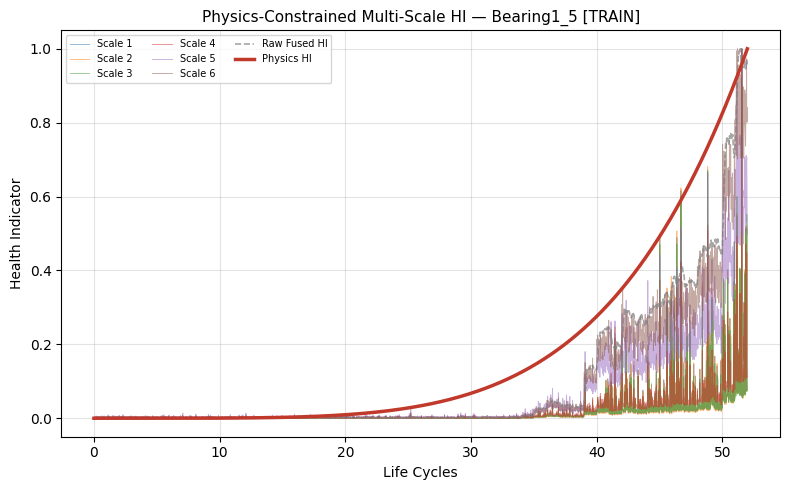

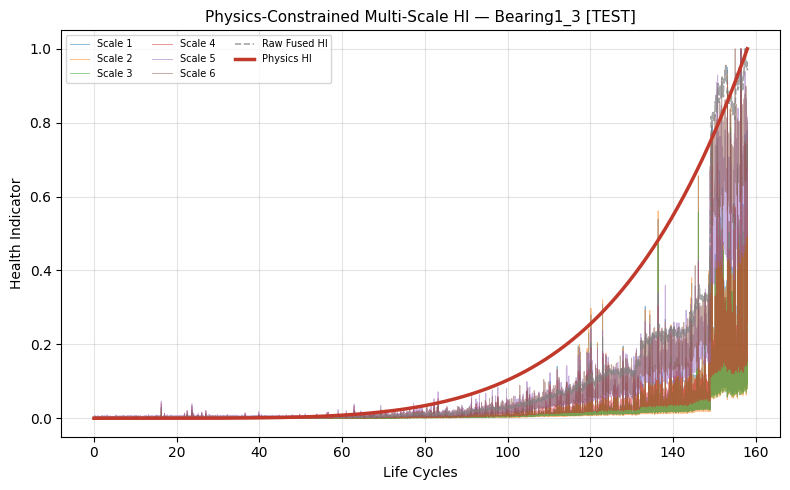

In [10]:
# =======================
# MULTI-SCALE + PHYSICS HI PLOT (CLEAN VERSION)
# =======================

windows_per_cycle = 32768 // WINDOW_SIZE

SCALE_COLORS = [
    "#1f77b4",
    "#ff7f0e",
    "#2ca02c",
    "#d62728",
    "#9467bd",
    "#8c564b"
]

for b in ALL_BEARINGS:

    fig, ax = plt.subplots(figsize=(8,5))

    n_windows = len(HI_data[b])
    life_cycles = np.arange(n_windows) / windows_per_cycle

    # ---- plot RAW multi-scale (NO smoothing) ----
    for s in range(MULTI_SCALE_HI[b].shape[0]):

        hi_s = MULTI_SCALE_HI[b][s]

        # normalize each scale
        hi_s = (hi_s - hi_s.min()) / (hi_s.max() - hi_s.min() + 1e-8)

        ax.plot(
            life_cycles,
            hi_s,
            color=SCALE_COLORS[s % len(SCALE_COLORS)],
            lw=0.7,
            alpha=0.5,
            label=f"Scale {s+1}"
        )

    # ---- plot RAW fused HI (optional, for comparison) ----
    if 'HI_raw_data' in globals():
        ax.plot(
            life_cycles,
            HI_raw_data[b],
            color="gray",
            lw=1.2,
            alpha=0.7,
            linestyle="--",
            label="Raw Fused HI"
        )

    # ---- plot PHYSICS HI (main result) ----
    ax.plot(
        life_cycles,
        HI_data[b],
        color="#C0392B",
        lw=2.5,
        label="Physics HI",
        zorder=5
    )

    marker = " [TEST]" if b == TEST_BEARING else " [TRAIN]"

    ax.set_title(
        f"Physics-Constrained Multi-Scale HI — {b}{marker}",
        fontsize=11
    )

    ax.set_xlabel("Life Cycles")
    ax.set_ylabel("Health Indicator")

    ax.grid(True, alpha=0.35)

    ax.legend(fontsize=7, ncol=3, loc="upper left")

    plt.tight_layout()
    plt.show()

## 9 · RUL Labels & Sliding-Window Dataset

In [11]:
# Paper Table 1 lifetimes (minutes)
LIFETIMES = {
    "Bearing1_1":123, "Bearing1_2":161, "Bearing1_3":158,
    "Bearing1_4":122, "Bearing1_5": 52,
}

def make_rul_labels(b, n_windows):
    """
    Match RUL to windows.
    Each minute produces (32768 // WINDOW_SIZE) windows.
    RUL is normalised to [0,1].
    """
    T = LIFETIMES.get(b, raw_data[b].shape[0])
    wpmin = max(1, 32768 // WINDOW_SIZE)   # windows per minute
    rul_minute = np.arange(T, 0, -1) / T   # (T,) normalised RUL per minute
    rul_windows = np.repeat(rul_minute, wpmin)[:n_windows]
    # if windows > rul array, tile the last value
    if len(rul_windows) < n_windows:
        rul_windows = np.pad(rul_windows, (0, n_windows-len(rul_windows)),
                             mode='edge')
    return rul_windows.astype(np.float32)

# Build RUL arrays
RUL_data = {}
for b in ALL_BEARINGS:
    RUL_data[b] = make_rul_labels(b, len(HI_data[b]))
    print(f"  {b}: hi={len(HI_data[b])} windows, "
          f"rul=[{RUL_data[b][0]:.3f}→{RUL_data[b][-1]:.3f}]")

def create_dataset(seq_len=SEQ_LEN):
    """Sliding-window sequences of HI → scalar RUL at end of window."""
    X_tr, y_tr, X_te, y_te = [], [], [], []
    train_counts = {b: 0 for b in TRAIN_BEARINGS}
    test_count = 0

    for b in ALL_BEARINGS:
        hi  = HI_data[b]
        rul = RUL_data[b]
        for i in range(len(hi)-seq_len):
            seq   = hi[i:i+seq_len]
            label = rul[i+seq_len]
            if b == TEST_BEARING:
                X_te.append(seq); y_te.append(label)
                test_count += 1
            else:
                X_tr.append(seq); y_tr.append(label)
                train_counts[b] += 1

    print("\nRUL sequence counts per bearing:")
    for b in TRAIN_BEARINGS:
        print(f"  {b}: {train_counts[b]} sequences")
    print(f"  {TEST_BEARING}: {test_count} sequences (test)")

    return (torch.tensor(X_tr, dtype=torch.float32),
            torch.tensor(y_tr, dtype=torch.float32),
            torch.tensor(X_te, dtype=torch.float32),
            torch.tensor(y_te, dtype=torch.float32))

X_train, y_train, X_test, y_test = create_dataset(SEQ_LEN)

# Create a validation split from the training bearings only.
VAL_FRAC = 0.2
rng = np.random.default_rng(42)
perm = rng.permutation(len(X_train))
val_size = int(len(X_train) * VAL_FRAC)
val_idx = perm[:val_size]
train_idx = perm[val_size:]

X_val, y_val = X_train[val_idx], y_train[val_idx]
X_train, y_train = X_train[train_idx], y_train[train_idx]

print(f"\nDataset: X_train={tuple(X_train.shape)}, y_train={tuple(y_train.shape)}")
print(f"         X_val  ={tuple(X_val.shape)},  y_val  ={tuple(y_val.shape)}")
print(f"         X_test ={tuple(X_test.shape)},  y_test ={tuple(y_test.shape)}")

  Bearing1_1: hi=7872 windows, rul=[1.000→0.008]
  Bearing1_2: hi=10304 windows, rul=[1.000→0.006]
  Bearing1_5: hi=3328 windows, rul=[1.000→0.019]
  Bearing1_3: hi=10112 windows, rul=[1.000→0.006]

RUL sequence counts per bearing:
  Bearing1_1: 7792 sequences
  Bearing1_2: 10224 sequences
  Bearing1_5: 3248 sequences
  Bearing1_3: 10032 sequences (test)

Dataset: X_train=(17012, 80), y_train=(17012,)
         X_val  =(4252, 80),  y_val  =(4252,)
         X_test =(10032, 80),  y_test =(10032,)


## 10 · CNN-BiLSTM Predictor with Optuna Best Hyperparameters
**Applied:** `hidden=64`, `dropout=0.200`, from Optuna trial 10 (RMSE=0.1143).  
**Loss:** weighted MSE = `mean((1 + 3*(1-y)) * (ŷ-y)²)` — penalises early-life errors more.


In [12]:
class CNN_BiLSTM(nn.Module):
    """
    CNN-BiLSTM RUL predictor.
    Architecture from HyperP_Tune; hidden_size & dropout from Optuna best.
    """
    def __init__(self, hidden_size=HIDDEN_SIZE, dropout_rate=DROPOUT_RATE):
        super().__init__()
        self.cnn = nn.Sequential(
            nn.Conv1d(1, 64, 3, padding=1), nn.BatchNorm1d(64),  nn.ReLU(),
            nn.Conv1d(64,128, 3, padding=1), nn.BatchNorm1d(128), nn.ReLU(),
        )
        self.lstm = nn.LSTM(
            128, hidden_size,
            num_layers=2, batch_first=True, bidirectional=True,
            dropout=dropout_rate
        )
        self.dropout = nn.Dropout(dropout_rate)
        self.fc = nn.Linear(hidden_size*2, 1)

    def forward(self, x):
        # x: (B, seq_len)
        h = self.cnn(x.unsqueeze(1))       # (B,128,seq_len)
        h = h.permute(0,2,1)               # (B,seq_len,128)
        out, _ = self.lstm(h)
        out = self.dropout(out[:,-1,:])    # last time step
        return torch.sigmoid(self.fc(out)).squeeze(1)

def weighted_mse(pred, target):
    """From HyperP_Tune: weight = 1+3*(1-target), emphasises end-of-life accuracy."""
    w = 1 + 3*(1 - target.clamp(0,1))
    return (w * (pred-target)**2).mean()

# Verify shape
_m = CNN_BiLSTM().to(DEVICE)
_x = torch.randn(8, SEQ_LEN).to(DEVICE)
_o = _m(_x)
print(f"CNN-BiLSTM OK: input {tuple(_x.shape)} → output {tuple(_o.shape)}")
del _m, _x, _o


CNN-BiLSTM OK: input (8, 80) → output (8,)


## 11 · Train CNN-BiLSTM with Best Checkpoint Saving

In [13]:
# =======================
# IMPROVED RUL TRAINING (PHYSICS-AWARE)
# =======================

loader_rul = DataLoader(
    TensorDataset(X_train, y_train),
    batch_size=BATCH_SIZE,
    shuffle=True
)

final_model = CNN_BiLSTM(HIDDEN_SIZE, DROPOUT_RATE).to(DEVICE)

optimizer_rul = torch.optim.Adam(
    final_model.parameters(),
    lr=LR_RUL,
    weight_decay=1e-5
)

scheduler_rul = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer_rul,
    T_max=EPOCHS_RUL,
    eta_min=1e-6
)

# -------- NEW: better loss --------
def physics_weighted_mse(pred, target):
    # higher weight near failure (low RUL)
    weights = 1.0 + 2.0 * (1 - target / (target.max() + 1e-6))
    return torch.mean(weights * (pred - target)**2)

print("Training on bearings:", TRAIN_BEARINGS)
print("Validation split: random 20% of training sequences")
print("Held-out test bearing:", TEST_BEARING)
print("Train/val/test shapes:", X_train.shape, X_val.shape, X_test.shape)

assert X_train.shape[0] > 0, "No training sequences. Check TRAIN_BEARINGS or SEQ_LEN."
assert X_val.shape[0] > 0, "No validation sequences. Check VAL_FRAC or TRAIN_BEARINGS."
assert X_test.shape[0] > 0, "No test sequences. Check TEST_BEARING and SEQ_LEN."

# initial validation evaluation
final_model.eval()
with torch.no_grad():
    init_preds = final_model(X_val.to(DEVICE)).cpu().numpy()

best_rmse = float(np.sqrt(np.mean((init_preds - y_val.numpy())**2)))
best_state = copy.deepcopy(final_model.state_dict())

print(f"Initial validation RMSE: {best_rmse:.6f}")
best_epoch   = 0
patience     = 30
pat_counter  = 0

rmse_history = []
loss_history = []

print(f"Training for {EPOCHS_RUL} epochs | batch={BATCH_SIZE} lr={LR_RUL:.2e}")
print("-"*60)

t0 = time.time()

for epoch in range(EPOCHS_RUL):

    # ---- TRAIN ----
    final_model.train()
    ep_loss = 0

    for xb, yb in loader_rul:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)

        optimizer_rul.zero_grad()

        pred = final_model(xb)

        # use improved loss
        loss = physics_weighted_mse(pred, yb)

        loss.backward()
        nn.utils.clip_grad_norm_(final_model.parameters(), 1.0)

        optimizer_rul.step()
        ep_loss += loss.item()

    scheduler_rul.step()

    # ---- EVAL ----
    final_model.eval()
    with torch.no_grad():
        preds_ep = final_model(X_val.to(DEVICE)).cpu().numpy()

    ep_rmse = float(np.sqrt(np.mean((preds_ep - y_val.numpy())**2)))

    rmse_history.append(ep_rmse)
    loss_history.append(ep_loss / len(loader_rul))

    # ---- CHECKPOINT ----
    if ep_rmse < best_rmse:
        best_rmse  = ep_rmse
        best_state = copy.deepcopy(final_model.state_dict())
        best_epoch = epoch + 1
        print(f"  Ep {epoch+1:>3}: new best validation RMSE = {best_rmse:.6f}")

    else:
        pat_counter += 1

    # ---- EARLY STOP ----
    if pat_counter > patience:
        print(f"\nEarly stopping at epoch {epoch+1}")
        break


# ---- LOAD BEST ----
final_model.load_state_dict(best_state)
final_model.eval()
print(f"  Best epoch       : {best_epoch}")
print(f"{'='*60}")
print(f"  Best epoch            : {best_epoch}")
print(f"  Best validation RMSE  : {best_rmse:.6f}")
print(f"  Training time         : {time.time()-t0:.1f}s")
print(f"{'='*60}")


Training on bearings: ['Bearing1_1', 'Bearing1_2', 'Bearing1_5']
Validation split: random 20% of training sequences
Held-out test bearing: Bearing1_3
Train/val/test shapes: torch.Size([17012, 80]) torch.Size([4252, 80]) torch.Size([10032, 80])
Initial validation RMSE: 0.284483
Training for 150 epochs | batch=16 lr=9.25e-04
------------------------------------------------------------
  Ep   1: new best validation RMSE = 0.076943
  Ep   3: new best validation RMSE = 0.075940
  Ep   6: new best validation RMSE = 0.067614
  Ep   8: new best validation RMSE = 0.049030
  Ep  10: new best validation RMSE = 0.045348
  Ep  11: new best validation RMSE = 0.038032
  Ep  20: new best validation RMSE = 0.023909

Early stopping at epoch 38
  Best epoch       : 20
  Best epoch            : 20
  Best validation RMSE  : 0.023909
  Training time         : 2229.1s


## 12 · Training Curves

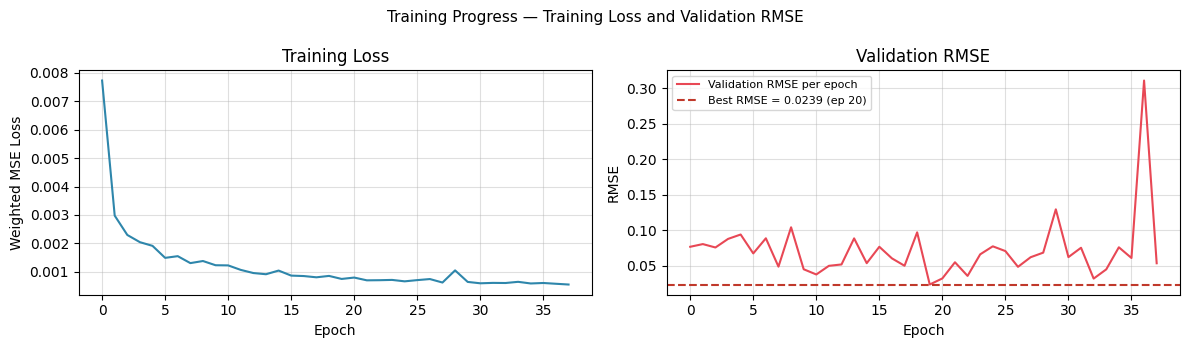

In [14]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12,3.5))

ax1.plot(loss_history, color="#2E86AB", lw=1.5)
ax1.set_xlabel("Epoch"); ax1.set_ylabel("Weighted MSE Loss")
ax1.set_title("Training Loss"); ax1.grid(True,alpha=0.4)

ax2.plot(rmse_history, color="#E84855", lw=1.5, label="Validation RMSE per epoch")
ax2.axhline(best_rmse,  color="#C0392B", lw=1.5, ls="--",
            label=f"Best RMSE = {best_rmse:.4f} (ep {best_epoch})")
ax2.set_xlabel("Epoch"); ax2.set_ylabel("RMSE")
ax2.set_title("Validation RMSE"); ax2.grid(True,alpha=0.4)
ax2.legend(fontsize=8)

plt.suptitle("Training Progress — Training Loss and Validation RMSE", fontsize=11)
plt.tight_layout()
plt.savefig("training_curves.png", dpi=150, bbox_inches="tight")
plt.show()


## 13 · Final RUL Prediction — Bearing1_3

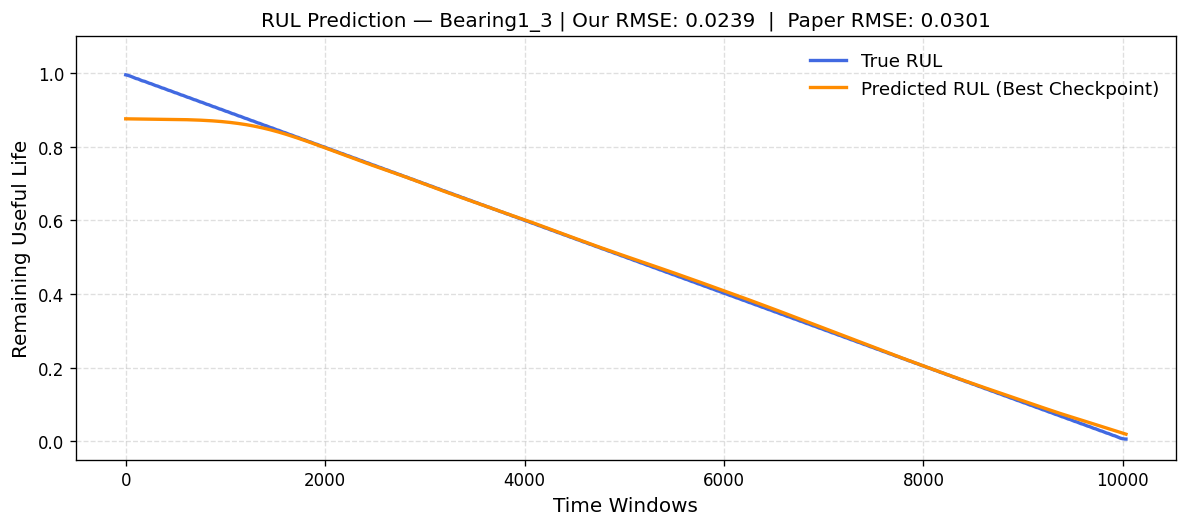

In [15]:
final_model.eval()
with torch.no_grad():
    raw_preds = final_model(X_test.to(DEVICE)).cpu().numpy()

true_rul  = y_test.numpy()
pred_rul  = raw_preds

# Dynamic Savitzky-Golay smoothing (from HyperP_Tune plot cell)
def safe_savgol(arr, max_win, polyorder):
    win = min(max_win, len(arr)-1 if len(arr)%2==0 else len(arr))
    win = max(win, polyorder+2) if win%2==0 else max(win,polyorder+1)
    return savgol_filter(arr, win, polyorder)

true_smooth = safe_savgol(true_rul,  151,  3)
pred_smooth = safe_savgol(pred_rul, 1001,  1)

fig, ax = plt.subplots(figsize=(10,4.5), dpi=120)
ax.plot(true_smooth, color="royalblue",   lw=2,   label="True RUL")
ax.plot(pred_smooth, color="darkorange",  lw=2,   label="Predicted RUL (Best Checkpoint)")
ax.set_xlabel("Time Windows", fontsize=12)
ax.set_ylabel("Remaining Useful Life", fontsize=12)
ax.set_title(
    f"RUL Prediction — Bearing1_3 | "
    f"Our RMSE: {best_rmse:.4f}  |  Paper RMSE: {PAPER_RMSE:.4f}",
    fontsize=12
)
ax.legend(frameon=False, fontsize=11)
ax.grid(True, ls="--", alpha=0.4)
ax.set_ylim(-0.05,1.1)
plt.tight_layout()
plt.savefig("rul_prediction_bearing1_3.png", dpi=150, bbox_inches="tight")
plt.show()


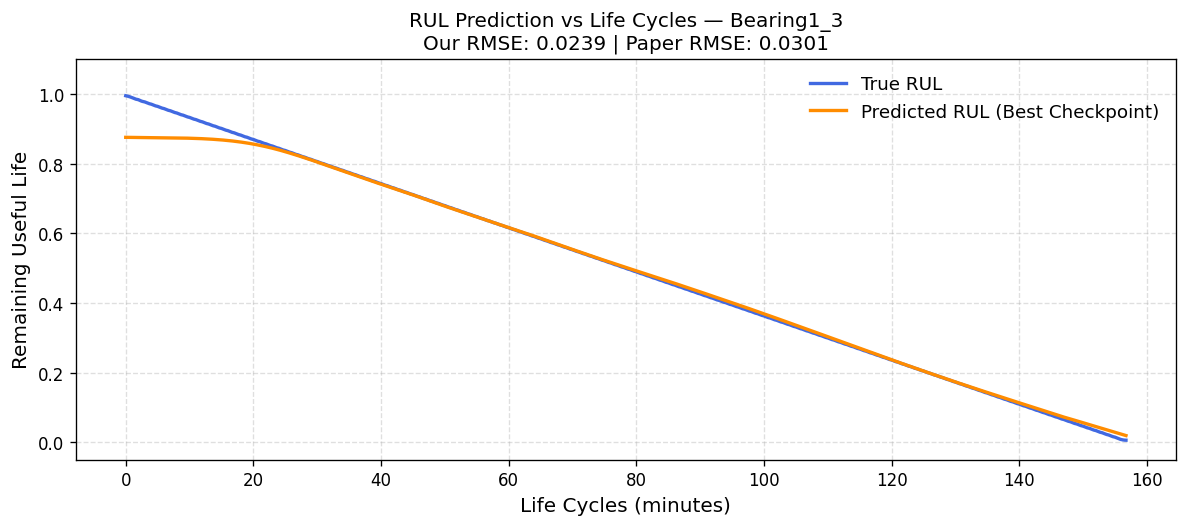

In [16]:
windows_per_cycle = 32768 // WINDOW_SIZE

final_model.eval()

with torch.no_grad():

    raw_preds = final_model(

        X_test.to(DEVICE)

    ).cpu().numpy()


true_rul = y_test.numpy()

pred_rul = raw_preds


# smoothing
def safe_savgol(arr, max_win, polyorder):

    win = min(

        max_win,

        len(arr)-1 if len(arr)%2==0 else len(arr)

    )

    win = max(

        win,

        polyorder+2

    ) if win%2==0 else max(

        win,

        polyorder+1

    )

    return savgol_filter(arr, win, polyorder)


true_smooth = safe_savgol(true_rul, 151, 3)

pred_smooth = safe_savgol(pred_rul, 1001, 1)


# convert window index → life cycles
life_cycles = np.arange(len(true_smooth)) / windows_per_cycle


fig, ax = plt.subplots(figsize=(10,4.5), dpi=120)


ax.plot(

    life_cycles,

    true_smooth,

    color="royalblue",

    lw=2,

    label="True RUL"

)


ax.plot(

    life_cycles,

    pred_smooth,

    color="darkorange",

    lw=2,

    label="Predicted RUL (Best Checkpoint)"

)


ax.set_xlabel(

    "Life Cycles (minutes)",

    fontsize=12

)


ax.set_ylabel(

    "Remaining Useful Life",

    fontsize=12

)


ax.set_title(

    f"RUL Prediction vs Life Cycles — Bearing1_3\n"

    f"Our RMSE: {best_rmse:.4f} | "

    f"Paper RMSE: {PAPER_RMSE:.4f}",

    fontsize=12

)


ax.legend(

    frameon=False,

    fontsize=11

)


ax.grid(

    True,

    ls="--",

    alpha=0.4

)


ax.set_ylim(-0.05,1.1)


plt.tight_layout()


plt.savefig(

    "rul_prediction_bearing1_3_lifecycle.png",

    dpi=150,

    bbox_inches="tight"

)


plt.show()